## Problem statement

The objective of this project is to build a regression model to predict the band gap of materials. I am using the matbench_expt_gap dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org), which consists of approximately 4,604 samples. Each entry includes:

* Input: A chemical composition (e.g., "Fe2O3").

* Target: A continuous value representing the experimental band gap in electron volts (eV).


The model will be evaluated using regression metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). According to the official MatBench leaderboard, the top-performing models achieve MAE values around 0.3327 eV.

This project aims to investigate whether accurate predictions can be achieved using only composition-only features, in combination with Random Forest and XGBoost regression models.

## Data preparation

In [ ]:
# Installation of libraries (Datasets and featurisation )
%pip install matminer --quiet

In [1]:
# Get dataset info from matminer
from matminer.datasets import get_all_dataset_info
from matminer.datasets import load_dataset

CID = 6046262

# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code 

  # A 
#info = get_all_dataset_info("matbench_dielectric")

  # B 
info = get_all_dataset_info("matbench_expt_gap")

  # C 
#info = get_all_dataset_info("matbench_expt_is_metal")

  # D 
#info = get_all_dataset_info("matbench_glass")

  # E 
#info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_expt_gap
Description: Matbench v0.1 test dataset for predicting experimental band gap from composition alone. Retrieved from Zhuo et al. supplementary information. Deduplicated according to composition, removing compositions with reported band gaps spanning more than a 0.1eV range; remaining compositions were assigned values based on the closest experimental value to the mean experimental value for that composition among all reports. For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	gap expt: Target variable. Experimentally measured gap, in eV.
Num Entries: 4604
Reference: Y. Zhuo, A. Masouri Tehrani, J. Brgoch (2018) Predicting the Band Gaps of Inorganic Solids by Machine Learning J. Phys. Chem. Lett. 2018, 9, 7, 1668-1673 https:doi.org/10.1021/acs.jpclett.8b00124.
Bibtex citations: ["@Article{Dunn2020

     chemical_composition  gap expt
0                Ag(AuS)2      0.00
1              Ag(W3Br7)2      0.00
2        Ag0.5Ge1Pb1.75S4      1.83
3       Ag0.5Ge1Pb1.75Se4      1.51
4                  Ag2BBr      0.00
...                   ...       ...
4599               ZrTaN3      1.72
4600                 ZrTe      0.00
4601               ZrTi2O      0.00
4602               ZrTiF6      0.00
4603                 ZrW2      0.00

[4604 rows x 2 columns]
Number of samples: 4604
Mean band gap: 0.9760 eV
Median band gap: 0.0000 eV
Min band gap: 0.0000 eV
Max band gap: 11.7000 eV
Standard deviation: 1.4450 eV


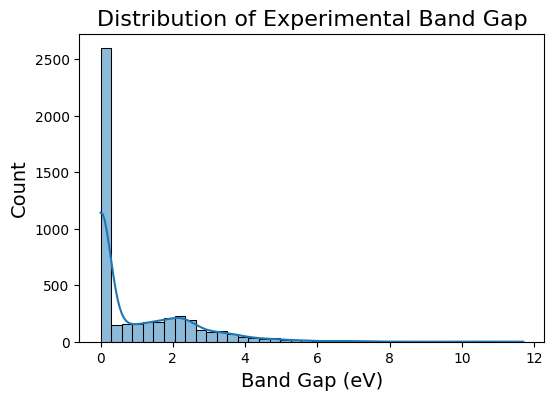

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset into a pandas DataFrame
df = load_dataset("matbench_expt_gap")
df = df.rename(columns={"composition": "chemical_composition"})
print(df)

# Basic statistics
print(f"Number of samples: {len(df)}")
print(f"Mean band gap: {df['gap expt'].mean():.4f} eV")
print(f"Median band gap: {df['gap expt'].median():.4f} eV")
print(f"Min band gap: {df['gap expt'].min():.4f} eV")
print(f"Max band gap: {df['gap expt'].max():.4f} eV")
print(f"Standard deviation: {df['gap expt'].std():.4f} eV")

# Distribution plot
plt.figure(figsize=(6, 4))
sns.histplot(df['gap expt'], bins=40, kde=True)
plt.title('Distribution of Experimental Band Gap', fontsize=16)
plt.xlabel('Band Gap (eV)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

In [3]:
# Convert chemical formula strings into Composition objects
from matminer.featurizers.conversions import StrToComposition
stc = StrToComposition()
df = stc.featurize_dataframe(df, "chemical_composition", pbar=False)

# Apply the ElementProperty featuriser to calculate features based on the elements.
from matminer.featurizers.composition.composite import ElementProperty
el_prop_featuriser = ElementProperty.from_preset(preset_name='magpie')
df = el_prop_featuriser.featurize_dataframe(df, col_id='composition', pbar=False)

# Print the shape of the DataFrame
print(df.shape)
df.head()


(4604, 135)


,chemical_composition,gap expt,composition,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,Ag(AuS)2,0.00,"(Ag, Au, S)",16.0,79.0,63.0,47.400000,25.280000,16.0,65.0,...,0.0,0.0,0.0,0.0,70.0,225.0,155.0,163.000000,74.400000,70.0
1,Ag(W3Br7)2,0.00,"(Ag, W, Br)",35.0,74.0,39.0,46.714286,15.619048,35.0,51.0,...,0.0,0.0,0.0,0.0,64.0,229.0,165.0,118.809524,73.079365,64.0
2,Ag0.5Ge1Pb1.75S4,1.83,"(Ag, Ge, Pb, S)",16.0,82.0,66.0,36.275862,23.552913,16.0,65.0,...,0.0,0.0,0.0,0.0,70.0,225.0,155.0,139.482759,76.670630,70.0
3,Ag0.5Ge1Pb1.75Se4,1.51,"(Ag, Ge, Pb, Se)",32.0,82.0,50.0,46.206897,17.388823,34.0,65.0,...,0.0,0.0,0.0,0.0,14.0,225.0,211.0,108.586207,104.370987,14.0
4,Ag2BBr,0.00,"(Ag, B, Br)",5.0,47.0,42.0,33.500000,14.250000,47.0,65.0,...,0.0,0.0,0.0,0.0,64.0,225.0,161.0,170.000000,55.000000,225.0


In [4]:
# Check for missing values
df.isna().sum()

chemical_composition                   0
gap expt                               0
composition                            0
MagpieData minimum Number              0
MagpieData maximum Number              0
                                      ..
MagpieData maximum SpaceGroupNumber    0
MagpieData range SpaceGroupNumber      0
MagpieData mean SpaceGroupNumber       0
MagpieData avg_dev SpaceGroupNumber    0
MagpieData mode SpaceGroupNumber       0
Length: 135, dtype: int64

In [5]:
# Remove rows containing NaN
df = df.dropna()

# Separate features and target
X = df.drop(columns=['chemical_composition', 'composition', 'gap expt'])
y = df['gap expt']

print(f"Final number of features: {X.shape[1]}")

Final number of features: 132


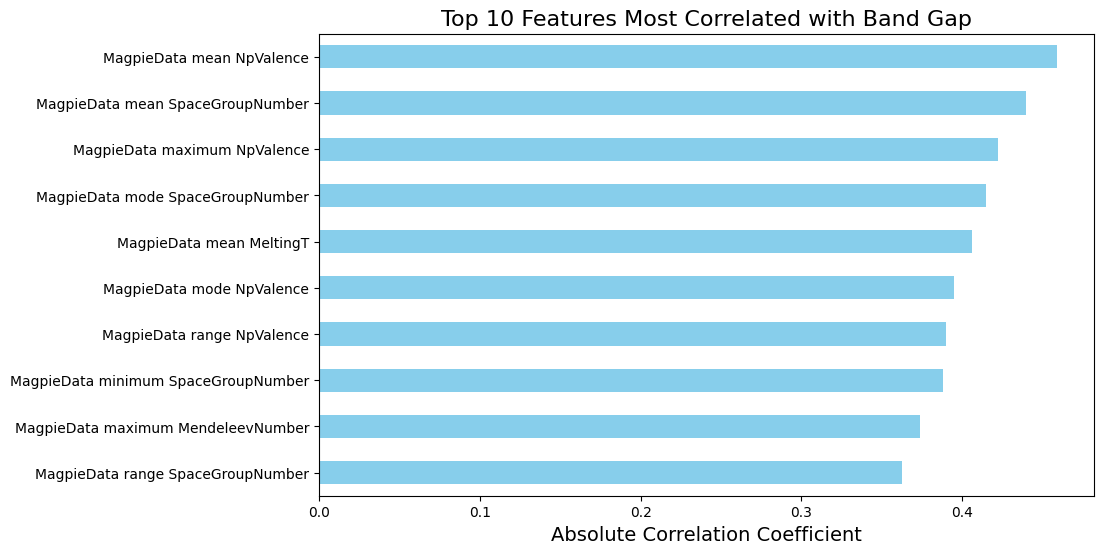

In [6]:
# Feature correlation analysis (select the top 10 features most correlated with the target)
correlations = X.corrwith(y).abs().sort_values(ascending=False)
top_10_features = correlations.head(10)

plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh', color='skyblue')
plt.title('Top 10 Features Most Correlated with Band Gap', fontsize=16)
plt.xlabel('Absolute Correlation Coefficient', fontsize=14)
plt.gca().invert_yaxis()
plt.show()

Choose relevant features, which may be based on composition or structure, depending on your problem. [matminer](https://hackingmaterials.lbl.gov/matminer/) is a good place to start.

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

### Model Justification

For this materials science regression problem, Random Forest and XGBoost were selected and compared as the primary machine learning models for the following reasons.

1. Nonlinear Modeling: The relationship between chemical composition and band gap is highly nonlinear and complex. Tree-based models, such as Random Forest and XGBoost, can naturally capture nonlinear dependencies and interactions between elemental features without requiring explicit functional forms.

2. Robustness: Composition-based descriptors often result in high-dimensional feature spaces with correlated and heterogeneous features. Both Random Forest and XGBoost handle multicollinearity well and can implicitly select relevant features through their tree-based splitting mechanisms, making them robust choices for composition-only featurization.

3. Overfitting Prevention: Overfitting prevention is addressed through systematic hyperparameter optimization using cross-validation. Key hyperparameters such as `max_depth`, `min_samples_split`, and `learning_rate` were tuned via `GridSearchCV` to balance model complexity and generalization performance on unseen data.

### Training and Validation Procedure

* The dataset was divided into training and test sets using an 80/20 split.

* Hyperparameter optimization was performed using 5-fold cross-validation, ensuring that model performance was evaluated across multiple data partitions. This approach reduces the bias introduced by a single train–test split and provides a more reliable estimate of model generalization performance.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import pandas as pd

# 1. Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=CID)

# 2. Setting up hyperparameters for Random Forest and XGBoost
model_params = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=CID),
        "params": {
            "n_estimators": [400],				# Number of trees
            # More trees reduce variance but increase computation.
            "max_depth": [10, 15, 20],			# Depth of trees
            # Deeper trees can capture more details but may overfit.
            "min_samples_split": [3, 5, 10],	# Minimum samples required to split a node
            # Larger values reduce overfitting.
            "max_features": ["sqrt"]			# Number of features considered at each split
            # 'sqrt' reduces correlation between trees.
        }
    },
    "XGBoost": {
        "model": XGBRegressor(objective='reg:squarederror',	# Regression objective
                              eval_metric='rmse',
                              random_state=CID,
                              tree_method="hist"			# Histogram-based tree method for faster training
                              ),
        "params": {
            "n_estimators": [400],				# Number of boosting rounds
            "max_depth": [3, 4, 5],				# Maximum depth of each tree
            # XGBoost uses shallow trees since multiple weak learners are combined, each correcting previous errors.
            "learning_rate": [0.03, 0.05],		# Step size shrinkage to prevent overfitting
            "min_child_weight": [3, 5],			# Minimum sum of instance weights (or number of samples) in a leaf
            "subsample": [0.7, 0.9],			# Fraction of training data used for each tree
            "colsample_bytree": [0.7, 0.9]		# Fraction of features used per tree
            # Using subsample and colsample_bytree < 1.0 helps reduce overfitting
        }
    }
}

In [17]:
from joblib import parallel_backend
import numpy as np

# Grid Search with Cross-Validation
best_models = {}
results = []

with parallel_backend('threading'):
	
	for name, config in model_params.items():
		grid = GridSearchCV(config["model"], config["params"], cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
		grid.fit(X_train, y_train)
		
		# The best model and results
		best_models[name] = grid.best_estimator_
		y_pred = grid.best_estimator_.predict(X_test)
		test_mae = mean_absolute_error(y_test, y_pred)
		test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
		
		results.append({
			"Model": name,
			"Best Params": grid.best_params_,
			"Validation MAE (Mean, CV)": -grid.best_score_,  # Because scoring is neg_mean_absolute_error
			"Test MAE": test_mae,
			"Test RMSE": test_rmse
		})

# Best Models for Random Forest and XGBoost
for result in results:
	print(f"Model: {result['Model']}")
	print(f"Best Params: {result['Best Params']}")
	print(f"Validation MAE (Mean, CV): {result['Validation MAE (Mean, CV)']:.4f}")
	print(f"Test MAE: {result['Test MAE']:.4f}")
	print(f"Test RMSE: {result['Test RMSE']:.4f}")
	print("----------------------------------------")

# Final Model Selection
performance_df = pd.DataFrame(results)
final_model_name = performance_df.sort_values("Test MAE").iloc[0]["Model"]
final_model = best_models[final_model_name]
print(f"Selected final model: {final_model_name}")

Model: Random Forest
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 3, 'n_estimators': 400}
Validation MAE (Mean, CV): 0.4604
Test MAE: 0.4591
Test RMSE: 0.8405
----------------------------------------
Model: XGBoost
Best Params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 400, 'subsample': 0.9}
Validation MAE (Mean, CV): 0.4355
Test MAE: 0.4311
Test RMSE: 0.8153
----------------------------------------
Selected final model: XGBoost


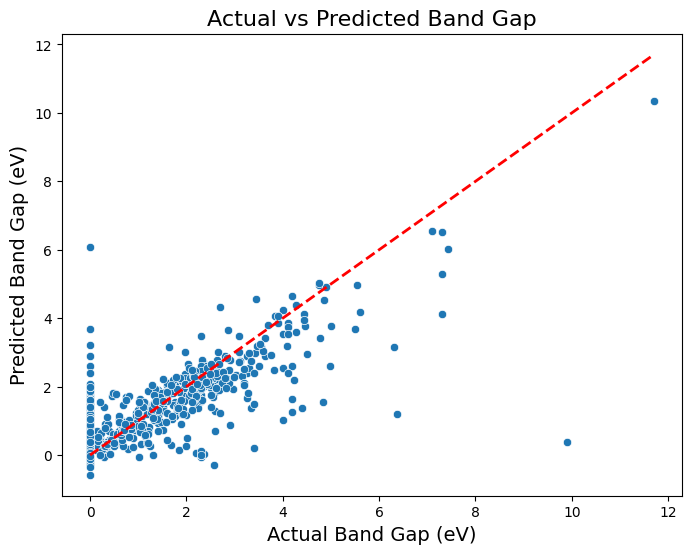

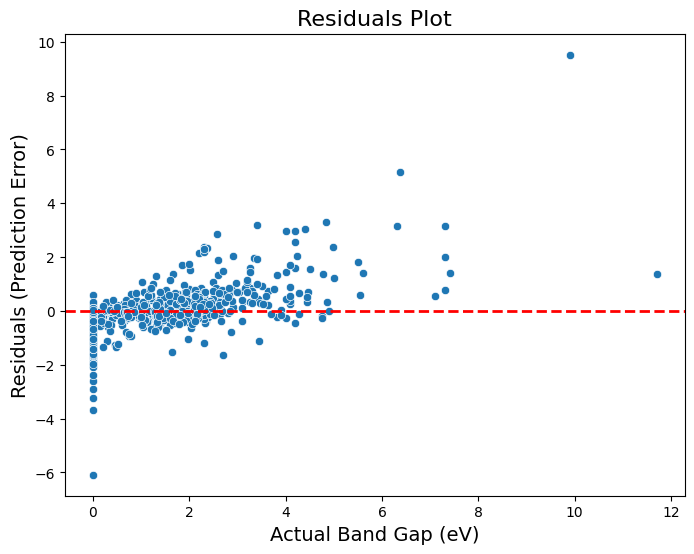

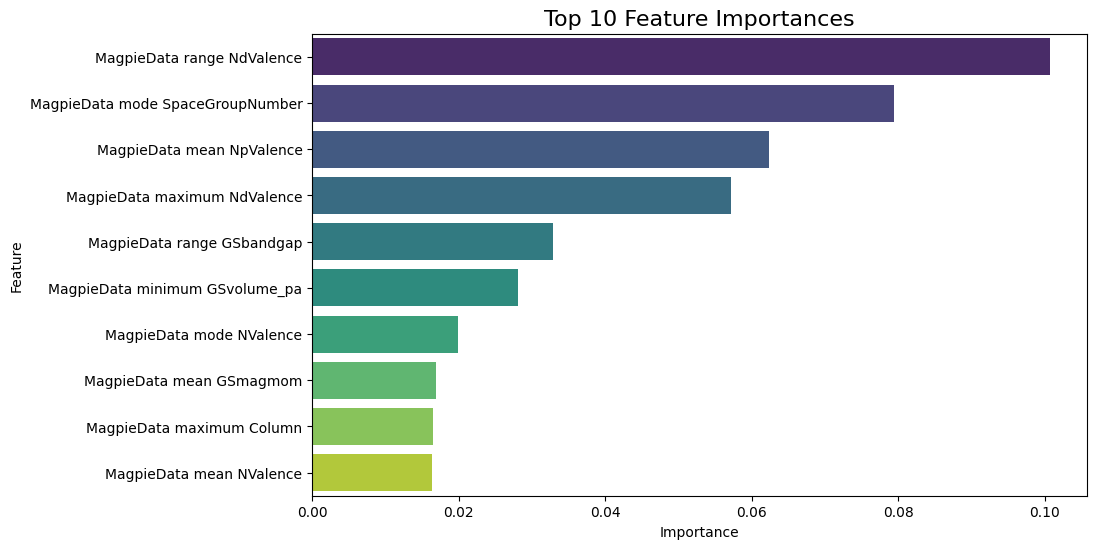

In [15]:
y_pred = final_model.predict(X_test)

# Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Band Gap (eV)', fontsize=14)
plt.ylabel('Predicted Band Gap (eV)', fontsize=14)
plt.title('Actual vs Predicted Band Gap', fontsize=16)
plt.show()

# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Actual Band Gap (eV)', fontsize=14)
plt.ylabel('Residuals (Prediction Error)', fontsize=14)
plt.title('Residuals Plot', fontsize=16)
plt.show()

# Top 10 Feature Importance
importances = final_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
top10_imp = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top10_imp, hue='Feature', palette='viridis')
plt.title('Top 10 Feature Importances', fontsize=16)
plt.show()

In [18]:
# Model Deployment: Real-time Predictor

def predict_bandgap(formula, mae=0.4311):
    """
    Predicts the experimental band gap (eV) of a compound given its chemical formula
    using the trained best-performing model.
    """
    import pandas as pd
    from pymatgen.core import Composition
    from matminer.featurizers.conversions import StrToComposition
    from matminer.featurizers.composition import ElementProperty

    try:
        # 1. Convert the formula string into a pymatgen Composition object
        tmp_df = pd.DataFrame({"formula": [formula]})
        tmp_df = StrToComposition().featurize_dataframe(tmp_df, "formula", pbar=False)
        
        # 2. Apply the same Magpie composition-based feature extractor used during training
        el_prop_featuriser = ElementProperty.from_preset(preset_name="magpie")
        tmp_df = el_prop_featuriser.featurize_dataframe(tmp_df, col_id="composition", pbar=False)
        
        # 3. Keep only the features used for training and ensure the same column order
        features = tmp_df[X.columns]
        
        # 4. Perform prediction
        bandgap_pred = max(0, final_model.predict(features)[0])
        
        # 5. Simple classification based on band gap
        if bandgap_pred < 0.1:
               label = "Metal (conductor)"
        elif bandgap_pred < 3:
               label = "Semiconductor"
        else:
               label = "Insulator"
        
        print(f"--- Predicted Band Gap for {formula} ---")
        print(f"Band Gap (eV): {bandgap_pred:.4f} ± {mae}")
        print(f"Classification: {label}")
        
    except Exception as e:
        print(f"Error processing formula {formula}: {e}")

# --- Test the predictor ---
predict_bandgap("Cu")      # Typical metal
predict_bandgap("NaCl")    # Typical non-metal
predict_bandgap("Si")      # Semiconductor / metalloid

--- Predicted Band Gap for Cu ---
Band Gap (eV): 0.0000 ± 0.4311
Classification: Metal (conductor)
--- Predicted Band Gap for NaCl ---
Band Gap (eV): 8.2513 ± 0.4311
Classification: Insulator
--- Predicted Band Gap for Si ---
Band Gap (eV): 1.6002 ± 0.4311
Classification: Semiconductor


## Model analysis and discussion

### 4.1 Benchmark Comparison

Model Performance: The final model achieved a mean absolute error (MAE) of 0.4311.

Comparison with MatBench: On the matbench_expt_is_metal task, the official [MatBench](https://matbench.materialsproject.org) benchmark score is 0.3327.

Discussion: Our model did not outperform the official benchmark. Even though Magpie composition-based descriptors provided by matminer were used, these descriptors are insufficient for accurately predicting the band gap. It may be necessary to rely on more complex structural information, as chemical composition alone cannot provide accurate predictions.

### 4.2 Feature Importance & Physical Significance

Through XGBoost feature importance analysis, we identified the three most critical descriptors for predicting bandgap:

1. Range Nd Valence (d-valence electron range)

	Physical significance: The range of d-valence electrons reflects the spread of d-orbital electron occupancy in the material, which directly affects the electronic band structure. A wider d-electron range can lead to more complex band interactions, influencing the band gap.

	In-depth analysis: Analysis of the dataset shows that elements with a large d-electron range, such as transition metals, significantly impact the band gap. This is because d-electrons can form localized orbitals that modify the energy difference between the valence and conduction bands. The model’s sensitivity to this feature indicates that electronic structure plays a dominant role in band gap prediction.

2. Space Group Number

	Physical significance: The space group number characterizes the crystal symmetry, which governs band folding and the formation of energy gaps. Therefore, it has a direct effect on the material’s band gap.

	In-depth analysis: High-symmetry crystal structures often lead to degenerate bands, while lower-symmetry structures can introduce band splitting and localized states, affecting the band gap width. The model’s reliance on the space group number highlights the importance of crystal structure, showing that chemical composition alone is insufficient for accurate band gap predictions.

3. Min Np Valence (Minimum d-valence electron count)

	Physical significance: The minimum p-valence electron count relates to the valence electronic configuration of main-group elements in the material, which directly influences the formation of the valence band maximum (VBM). Elements with more p-electrons tend to reduce the band gap, whereas elements with fewer p-electrons can increase it.

	In-depth analysis: The dataset indicates that the element with the lowest p-electron count controls the localization of the valence band and the bonding strength. The model’s sensitivity to this feature suggests that p-orbital electron distribution, together with d-electron characteristics, is critical for determining the electronic structure and thus the band gap.